In [244]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import re
import numpy as np

In [245]:
df = pd.read_stata('data/Politbarometer/dataset_cumul_1977.dta',convert_categoricals=False)
df

,v1,v2,Version,doi,v3,v4,V4a,v5,v6,v7,...,v72,v73,v74,v75,v76,v77,v78,v79,v80,V81
0,2391,1.0,"v15.2.0, 2025-01-28",doi:10.4232/1.14479,3,1977,2,1,1,99,...,2,2,2,5,5,0,1.640,0,3,0.000
1,2391,2.0,"v15.2.0, 2025-01-28",doi:10.4232/1.14479,3,1977,2,1,2,99,...,1,2,4,5,5,0,1.670,0,3,0.000
2,2391,3.0,"v15.2.0, 2025-01-28",doi:10.4232/1.14479,3,1977,2,1,1,99,...,2,3,4,5,5,0,0.650,0,3,0.000
3,2391,4.0,"v15.2.0, 2025-01-28",doi:10.4232/1.14479,3,1977,2,1,98,99,...,99,0,4,5,5,0,0.820,0,3,0.000
4,2391,5.0,"v15.2.0, 2025-01-28",doi:10.4232/1.14479,3,1977,2,1,1,99,...,2,3,4,5,5,0,1.670,0,3,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1046814,2391,501626.0,"v15.2.0, 2025-01-28",doi:10.4232/1.14479,12,2022,2,1,4,4,...,10,0,4,3,0,4,0.383,0,50,0.383
1046815,2391,501627.0,"v15.2.0, 2025-01-28",doi:10.4232/1.14479,12,2022,2,1,4,4,...,6,2,3,1,0,1,0.596,0,50,0.596
1046816,2391,501628.0,"v15.2.0, 2025-01-28",doi:10.4232/1.14479,12,2022,1,1,38,22,...,10,0,4,13,0,5,1.969,0,50,0.954
1046817,2391,501629.0,"v15.2.0, 2025-01-28",doi:10.4232/1.14479,12,2022,1,4,99,23,...,10,0,4,14,0,4,1.038,0,50,0.503


In [246]:
partie_codes = {
    1  : 'CDU',
    2  : 'SPD',
    3  : 'FDP',
    4  : 'Gruene',
    8  : 'NPD',
    49 : 'AfD',
    97 : 'undecided'
}

votes_partie_df = df[['v4', 'v6']]
votes_partie_df.loc[:,'v6'] = votes_partie_df['v6'].apply(lambda x: partie_codes[x] if x in partie_codes.keys() else x)

total_votes_per_year = pd.DataFrame(votes_partie_df.groupby(by=['v4']).size())

total_votes_per_year = total_votes_per_year.reset_index()
votes_partie_df = pd.DataFrame(votes_partie_df.groupby(by=['v4','v6']).size())

votes_partie_df = votes_partie_df.reset_index()
#votes_partie_df[0] = votes_partie_df[0] / total_votes_per_year[0]
votes_partie_df = votes_partie_df.set_index('v4')
total_votes_per_year = total_votes_per_year.set_index('v4')
votes_partie_df['total'] =  total_votes_per_year
votes_partie_df['vote percentage'] = votes_partie_df[0] / votes_partie_df['total']
votes_partie_df

/tmp/ipykernel_8313/767208015.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['CDU' 'SPD' 'CDU' ... 38 99 'CDU']' has dtype incompatible with int8, please explicitly cast to a compatible dtype first.
  votes_partie_df.loc[:,'v6'] = votes_partie_df['v6'].apply(lambda x: partie_codes[x] if x in partie_codes.keys() else x)


,v6,0,total,vote percentage
v4,,,,
1977,11,52,10151,0.005123
1977,98,1157,10151,0.113979
1977,99,643,10151,0.063344
1977,CDU,3810,10151,0.375332
1977,FDP,822,10151,0.080977
...,...,...,...,...
2022,CDU,5677,26615,0.213301
2022,FDP,1478,26615,0.055533
2022,Gruene,5713,26615,0.214653


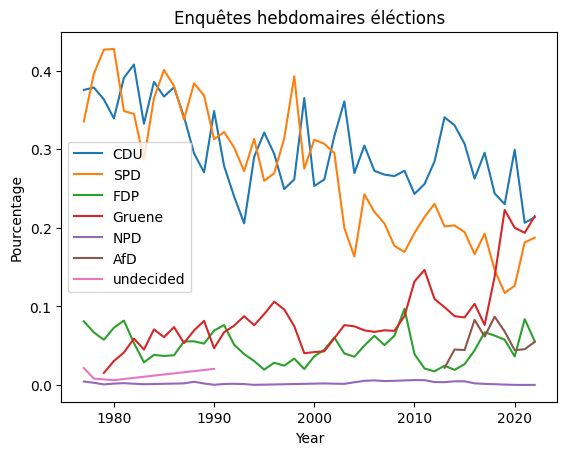

In [247]:
votes_partie_df = votes_partie_df.query(f'v6 in {list(partie_codes.values())}' )
for partie in partie_codes.values():
    votes_partie_df[votes_partie_df['v6'] == partie]['vote percentage'].plot(label=partie)
plt.xlabel('Year')
plt.ylabel('Pourcentage')
plt.title('Enquêtes hebdomaires éléctions')
plt.legend()
plt.show()

In [248]:
data = {
    1: {
        0: ["Renten", "Alterssicherung"],
    },
    5: {
        1986: ["Inflation"],
        1989: ["Wirtschaft", "Steuern", "Inflation"],
        1990: ["Steuern", "Steuererhöhung", "Gebühren", "Abgaben"],
        1993: ["Steuern", "Steuererhöhung", "Autobahngebühr"],
        1994: ["Steuern", "Steuererhöhung"],
        2006: ["Lebenshaltungskosten",  "Benzinpreise", "Teuro", "Inflation"],
        2013: ["Lebenshaltungskosten",  "Benzinpreise", "Teuro", "Inflation"],
        2015: ["Lebenshaltungskosten",  "Benzinpreise", "Inflation"],
    },
    10: {
        1986: ["Steuern", "Steuerreform"],
        1989: ["Wirtschaft", "Steuern", "Inflation"],
        1990: ["Steuern", "Steuererhöhung", "Gebühren", "Abgaben"],
        1993: ["Steuern", "Steuererhöhung", "Autobahngebühren"],
        1994: ["Steuern", "Steuererhöhungen"],
        2006: ["Steuern", "Steuererhöhungen"],
        2014: ["Steuern", "Steuererhöhungen", "Steuerhinterziehung"],
        2015: ["Steuern", "Steuererhöhungen", "Steuerhinterziehung"],
    },
    13: {
        1990: ["Wirtschaftspolitik"],
        1993: ["Wirtschaftspolitik", "Wirtschaftslage"],
        1994: ["Wirtschaftswachstum", "Wirtschaftslage"],
        2008: ["Rezession"],
        2011: ["Wirtschaftslage", "Rezession"],
        2012: ["Wirtschaftslage"],
        2020: ["Wirtschaftslage", "Konjunkturpaket", "Corona-Hilfen"],
    },
    14: {
        0: ["Arbeitslosigkeit", "Arbeitsplätze", "Ausbildungsplätze"],  # Entrée uniquement pour l'année de base
    },
    15: {
        1989: ["Umweltschutz"],
        1994: ["Umweltschutz", "Ozon"],
        1995: ["Umweltschutz", "Ölplattform Brent Spar"],
        2005: ["Umweltschutz", "Atomtransport"],
        2006: ["Umweltschutz", "Hochwasser", "Flut"],
        2007: ["Umweltschutz", "Klima", "Klimawandel"],
        2008: ["Erneuerbare Energien"],
        2012: ["Umweltschutz", "Klima", "Klimawandel", "Erneuerbare Energien", "Energiewende"],
        2013: ["Umweltschutz", "Klimawandel"],
        2016: ["Umweltschutz", "Klimawandel", "Klimagipfel"],
        2019: ["Umweltschutz", "Klimawandel", "Schutz von Insekten"],
        2020: ["Umweltschutz", "Klimawandel", "Artenschutz"],
    },
    19: {
        0: ["Kindergartenplätze"],  # Entrée uniquement pour l'année de base
        1996: ["Familie", "Kinder", "Jugend"],
    },
    20: {
        1989: ["Gesundheitsreform"],
        1990: ["Gesundheitswesen", "Pflegenotstand"],
        1994: ["Gesundheitswesen"],
        2006: ["Gesundheitswesen", "Pflegeversicherung"],
        2011: ["Gesundheitswesen", "Gesundheitsreform", "Pflegeversicherung"],
        2012: ["Gesundheitswesen", "Gesundheitspolitik", "Pflegeversicherung"],
        2014: ["Gesundheitswesen", "Gesundheitspolitik", "Pflegeversicherung"],
        2022: ["Gesundheitswesen", "Gesundheitspolitik", "Pflegeversicherung"],
    },
    23: {
        1986: ["Innere Sicherheit", "Kriminalität", "Terrorismus", "härtere Strafen", "Kronzeugenregelung"],
        1989: ["Innere Sicherheit", "Ruhe und Ordnung"],
        1990: ["Ruhe und Ordnung", "Kriminalität"],
        2008: ["Jugendkriminalität"],
        2011: ["Kriminalität", "Jugendkriminalität", "Ruhe und Ordnung"],
        2016: ["Kriminalität", "Ruhe und Ordnung", "mehr Polizei"],
        2019: ["Kriminalität", "Ruhe und Ordnung", "mehr Polizei", "Innere Sicherheit"],
        2020: ["Kriminalität", "Ruhe und Ordnung", "mehr Polizei", "Innere Sicherheit"],
        2021: ["Kriminalität", "Ruhe und Ordnung", "mehr Polizei", "Innere Sicherheit"],
    },
    27: {
        1986: ["Politische Moral", "Spendenaffären", "Flick"],
        1993: ["Partei Affäre", "Politikverdruß"],
        2001: ["Partei Affäre", "Politikverdruß", "Politik allgemein"],
        2002: ["Partei Affäre", "Politikverdruß"],
        2005: ["Partei Affäre", "Politikverdruß","Spenden affäre"],
        2006: ["Partei Affäre", "Politikverdruß"],
    },
    30: {
        1989: ["Bildungspolitik", "Schulpolitik"],
        1997: ["Studentenproteste", "Bildung"],
        1999: ["Schule", "Bildung"],
        2002: ["Schule", "Bildung", "Pisa"],
    },
    53: {
        1986: ["Ausländer", "Asylanten", "Aussiedler"],
        1989: ["Asylanten", "Asyl"],
        2005: ["Asylanten", "Asyl"],
        2018: ["Ausländerfeindlichkeit"],
    },
    54: {
        1989: ["Ausländer"],
        2002: ["Ausländer", "doppelte Staatsbürgerschaft"],
        2005: ["Ausländer", "Zuwanderung", "Asylanten", "Asyl"],
        2006: ["Ausländer", "Zuwanderung", "Integration", "Asyl"],
        2016: ["Ausländer", "Zuwanderung", "Integration", "Asyl", "Flüchtlinge"],
        2018: ["Ausländer", "Zuwanderung", "Integration", "Asyl", "Flüchtlinge", "BAMF"],
        2019: ["Ausländer", "Zuwanderung", "Integration", "Asyl", "Flüchtlinge"],
    },
    55: {
        1990: ["EU Krise", "Binnenmarkt"],
        1998: [ "EU Krise", "Binnenmarkt"],
        1999: [ "EU Krise", "Euro Krise"],
        2002: [ "EU Krise", "Euro Krise"],
        2005: [ "EU Krise", "Türkei-Beitritt"],
        2012: ["EU Krise",  "Euro Krise" ],
        2013: ["EU Krise",  "Euro Krise"  ],
        2014: ["EU Krise",  "Euro Krise"   ],
        2015: ["EU Krise",  "Euro Krise"   ],
        2017: ["EU Krise",  "Euro Krise", "Brexit"  ],
        2021: ["EU Krise",  "Euro Krise", "Brexit"   ],
    },
    56: {
        1992: ["Staatsverschuldung"],
        2012: ["Staatsverschuldung", "Verschuldung der Bundesländer"],
        2022: ["Staatsverschuldung", "Verschuldung der Bundesländer"],
    },
    58: {
        1990: ["Rechtsradikale", "Rechtsextreme"],
        1991: ["NPD"],
        1989: ["Rechtsextremismus", "Republikaner", "DVU"],
        2002: ["Rechtsradikale", "Rechtsextreme", "NPD"],
        2004: ["Rechtsradikale", "Rechtsextreme", "NPD", "Antisemitismus"],
        2012: ["Rechtsextreme", "NPD", "Antisemitismus", "Verfassungsschutz"],
        2016: ["Rechtsextreme", "NPD", "Antisemitismus"],
        2017: ["Rechtsradikale", "NPD"],
        2018: ["Rechtsradikale", "Rechtsextremismus", "Rechtspopulismus"],
        2019: ["Rechtsradikale", "Rechtsextremismus", "Rechtspopulismus"],
        2020: ["Rechtsradikale", "Rechtsextremismus", "Rechtspopulismus"],
        2021: ["Rechtsradikale", "Rechtsextremismus", "Rechtspopulismus"],
    },
    77: {
        1998: ["soziales Gefälle", "arm-reich"],
        2006: ["soziales Gefälle", "arm-reich", "Unterschicht"],
        2014: ["soziales Gefälle", "Gerechtigkeit", "arm-reich", "Unterschicht"],
    },
    117: {
        0: ["Finanzkrise","Bankenkrise"]
    },
    134: {
        0:["Coronavirus"],
        2020: ["Coronavirus", "neues Virus aus China", "Ausbreitung Virus"],
        2020: ["Coronavirus", "Ausbreitung Virus"],
        2021: ["Coronavirus", "Impfen", "Folgen für verschiedene Bereiche"],
        2022: ["Coronavirus", "Impfen", "Folgen pour verschiedene Bereiche"],
    }
}


In [249]:
problemes_survey_df = df[['v4', 'v33']]
#votes_partie_df.loc[:,'v33'] = votes_partie_df['v33'].apply(lambda x: dict_plus_grand_problemes[x] if x in dict_plus_grand_problemes.keys() else x)

problemes_survey_df = problemes_survey_df[~problemes_survey_df['v33'].isin([0,998,999])]

total = int(problemes_survey_df['v33'].count())


pb_percentage = pd.DataFrame(problemes_survey_df.groupby('v33').size() / total)
top_20_problems = list(pb_percentage.sort_values(by=0,ascending=False)[0:20].reset_index()['v33'])
problemes_survey_df = problemes_survey_df[problemes_survey_df['v33'].isin(top_20_problems)]


total_votes_per_year = pd.DataFrame(problemes_survey_df.groupby(by=['v4']).size())

total_votes_per_year = total_votes_per_year.reset_index()


In [250]:
print(problemes_survey_df)
problemes_survey_df = pd.DataFrame(problemes_survey_df.groupby(by=['v4','v33']).size())

problemes_survey_df = problemes_survey_df.reset_index()
#votes_partie_df[0] = votes_partie_df[0] / total_votes_per_year[0]
problemes_survey_df = problemes_survey_df.set_index('v4')
total_votes_per_year = total_votes_per_year.set_index('v4')
problemes_survey_df['total'] =  total_votes_per_year
print(problemes_survey_df)
problemes_survey_df['vote percentage'] = problemes_survey_df[0] / problemes_survey_df['total']
problemes_survey_df = problemes_survey_df.reset_index()

print(problemes_survey_df)

           v4  v33
98548    1986    1
98549    1986    1
98551    1986   14
98552    1986   14
98553    1986   14
...       ...  ...
1046804  2022   15
1046806  2022   58
1046810  2022   23
1046811  2022   15
1046813  2022    5

[736872 rows x 2 columns]
      v33     0  total
v4                    
1986    1   383   2926
1986    5    47   2926
1986   10    47   2926
1986   13   110   2926
1986   14  1287   2926
...   ...   ...    ...
2022   56    43  15266
2022   58   115  15266
2022   66   747  15266
2022   77   819  15266
2022  134  3528  15266

[621 rows x 3 columns]
       v4  v33     0  total  vote percentage
0    1986    1   383   2926         0.130895
1    1986    5    47   2926         0.016063
2    1986   10    47   2926         0.016063
3    1986   13   110   2926         0.037594
4    1986   14  1287   2926         0.439850
..    ...  ...   ...    ...              ...
616  2022   56    43  15266         0.002817
617  2022   58   115  15266         0.007533
618  2022   66   

In [251]:
data_lines = []
for year in range(2000,2023):
    data_line = []
    data_line.append(year)
    for question_code in top_20_problems:
        pc = problemes_survey_df[(problemes_survey_df['v4'] == year) & (problemes_survey_df['v33'] == question_code)]['vote percentage']
        if(len(pc) > 0):
            pc = float(pc.iloc[0])
        else:
            pc = 0
        data_line.append(pc)
    data_lines.append(data_line)
df_survey = pd.DataFrame(data_lines)
df_survey = df_survey.set_axis(['Year'] + top_20_problems,axis = 1)
print(top_20_problems)
df_survey = df_survey.set_index('Year')
df_survey

[14, 54, 13, 134, 27, 15, 77, 1, 55, 66, 30, 5, 117, 20, 10, 23, 19, 58, 53, 56]


,14,54,13,134,27,15,77,1,55,66,30,5,117,20,10,23,19,58,53,56
Year,,,,,,,,,,,,,,,,,,,,
2000,0.604920,0.045053,0.017358,0.000000,0.065782,0.015865,0.009563,0.053731,0.002598,0.019016,0.008071,0.010503,0.000000,0.008071,0.023825,0.023549,0.012548,0.067385,0.006965,0.005196
2001,0.627687,0.033893,0.042159,0.000000,0.051189,0.014435,0.009856,0.036309,0.022129,0.016787,0.011382,0.012527,0.000000,0.011192,0.012018,0.033003,0.015770,0.041651,0.004642,0.003370
2002,0.732455,0.019901,0.068533,0.000000,0.045247,0.006862,0.007228,0.011895,0.013862,0.013954,0.013588,0.010660,0.000000,0.005856,0.018071,0.007000,0.012261,0.003065,0.001281,0.008281
2003,0.684411,0.005873,0.092271,0.000000,0.056093,0.002146,0.007755,0.038324,0.000075,0.020969,0.007680,0.006099,0.000000,0.024470,0.026541,0.002033,0.007529,0.000866,0.000414,0.016451
2004,0.695264,0.010996,0.073670,0.000000,0.058883,0.000000,0.010883,0.029235,0.001201,0.015687,0.012159,0.009082,0.000000,0.036103,0.015687,0.002702,0.009570,0.002252,0.001013,0.015612
2005,0.801717,0.005750,0.049370,0.000000,0.043433,0.002327,0.009574,0.014602,0.000588,0.009574,0.008933,0.014629,0.000000,0.005536,0.008692,0.002166,0.008692,0.001043,0.000107,0.013265
2006,0.728740,0.014553,0.032658,0.000000,0.037174,0.002857,0.014167,0.025246,0.000347,0.000116,0.016715,0.019147,0.000000,0.050338,0.020884,0.004864,0.018954,0.002200,0.000000,0.011040
2007,0.574605,0.016833,0.025860,0.000000,0.045019,0.043876,0.039500,0.036819,0.001380,0.021445,0.027201,0.050972,0.000000,0.033035,0.019553,0.009698,0.042614,0.003430,0.000000,0.008160
2008,0.353843,0.015671,0.054773,0.000000,0.062724,0.020496,0.064963,0.036284,0.000502,0.015517,0.038252,0.125179,0.112286,0.016598,0.027367,0.018798,0.028409,0.002239,0.000000,0.006099


### Lire les dataframes scrappées

In [252]:
first = True
base_path = 'ScrappingJournaux/scrapping/de'
for file in os.listdir(base_path):
    with open(os.path.join(base_path,file), 'rb') as f:
        answer_code = int(re.findall('^\d+',file)[0])
        df = pd.read_pickle(f)
        if first:
            dfs_faz_all = pd.DataFrame(df['faz'].copy())
            dfs_faz_all = dfs_faz_all.rename(columns={'faz':answer_code})
            dfs_taz_all = pd.DataFrame(df['taz'].copy())
            dfs_taz_all = dfs_faz_all.rename(columns={'taz':answer_code})
            first = False
        else:
            dfs_faz_all[answer_code] = df['faz']
            dfs_taz_all[answer_code] = df['taz']

# normalize
dfs_faz_all = (dfs_faz_all-dfs_faz_all.min())/(dfs_faz_all.max()-dfs_faz_all.min())

dfs_taz_all = (dfs_taz_all-dfs_taz_all.min())/(dfs_taz_all.max()-dfs_taz_all.min())
#dfs_faz_all = dfs_faz_all.reset_index()
print(dfs_faz_all.columns.values)

[ 55  30  56  13  23  20 117  10  27   1  19  14 134   5  77  54  58  15
  53]


In [253]:
taz_corr = df_survey.corrwith(dfs_taz_all,axis = 0)
taz_corr

14     0.878950
54     0.830626
13     0.376440
134    0.997089
27     0.117063
15     0.670627
77     0.557141
1      0.196070
55     0.313979
30    -0.281229
5      0.139861
117    0.970349
20    -0.137206
10     0.425923
23     0.267214
19    -0.099488
58    -0.379292
53    -0.237381
56     0.865914
66          NaN
dtype: float64

In [254]:
faz_corr = df_survey.corrwith(dfs_faz_all, axis = 0)

In [255]:
corr_df = pd.DataFrame({"FAZ": faz_corr, "TAZ": taz_corr})
corr_df

,FAZ,TAZ
14,0.634284,0.878950
54,0.851865,0.830626
13,0.593774,0.376440
134,0.995999,0.997089
27,0.023394,0.117063
15,0.644369,0.670627
77,0.571615,0.557141
1,-0.127685,0.196070
55,0.313979,0.313979
30,0.412872,-0.281229


In [256]:
keywords_fr = {
    1: "Retraite",
    5: "Inflation",
    10: "Impôts",
    13: "Économie",
    14: "Chômage",
    15: "Environnement",
    19: "Famille",
    20: "Système de santé",
    23: "Sécurité intérieure",
    27: "Affaires politiques",
    30: "Éducation",
    53: "Asile",
    54: "Immigration",
    55: "Crise de l'UE",
    56: "Dette publique",
    58: "Extrémisme de droite",
    77: "Inégalités sociales",
    117: "Crise financière",
    134: "Coronavirus",
}

In [257]:
corr_df.index = corr_df.index.map(keywords_fr)
corr_df

,FAZ,TAZ
Chômage,0.634284,0.878950
Immigration,0.851865,0.830626
Économie,0.593774,0.376440
Coronavirus,0.995999,0.997089
Affaires politiques,0.023394,0.117063
Environnement,0.644369,0.670627
Inégalités sociales,0.571615,0.557141
Retraite,-0.127685,0.196070
Crise de l'UE,0.313979,0.313979
Éducation,0.412872,-0.281229


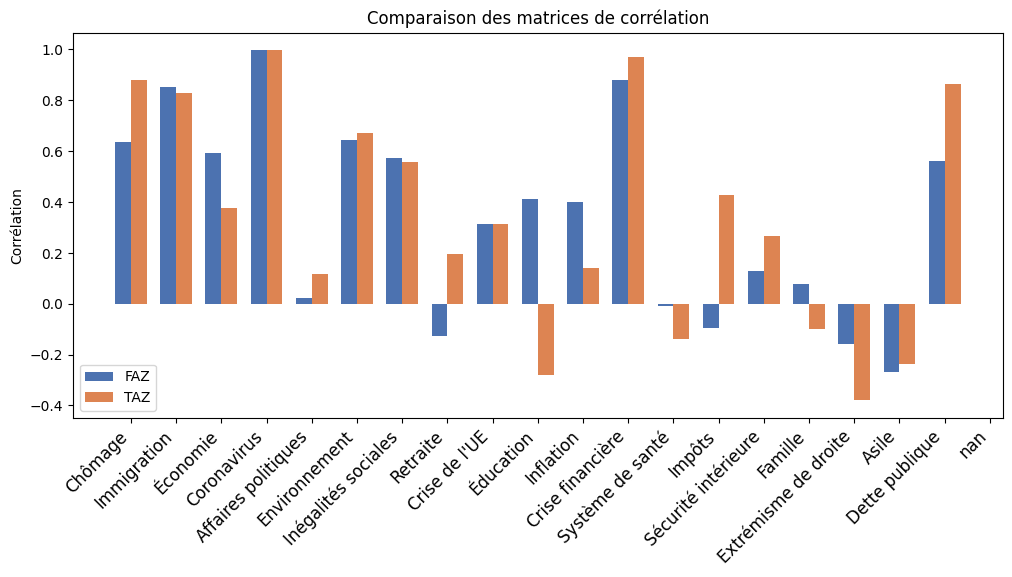

In [263]:


# Création des indices sous forme de catégories
indices = np.arange(len(corr_df))  # Positions pour les barres
width = 0.35  # Largeur des barres

# Tracé du graphique en barres
fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(indices - width/2, corr_df["FAZ"], width=width, label="FAZ", color='#4C72B0')
ax.bar(indices + width/2, corr_df["TAZ"], width=width, label="TAZ", color='#DD8452')

# Ajustements de l'axe des abscisses
ax.set_xticks(indices)
ax.set_xticklabels(corr_df.index, fontsize=12,rotation=45,ha="right")  # Affichage des indices distincts

# Labels et titre
ax.set_ylabel("Corrélation")
ax.set_title("Comparaison des matrices de corrélation")
ax.legend()

plt.show()


In [211]:
import numpy as np
index = ["a", "b", "c", "d"]
columns = ["one", "two", "three", "four"]
df1 = pd.DataFrame(np.arange(16).reshape(4, 4), index=index, columns=columns)
df2 = pd.DataFrame(np.arange(16).reshape(4, 4), index=index[:4], columns=columns)
df2['one'] = [2,2,2,4][::-1]
print(df1)

print(df2)
df2.corrwith(df1)

   one  two  three  four
a    0    1      2     3
b    4    5      6     7
c    8    9     10    11
d   12   13     14    15
   one  two  three  four
a    4    1      2     3
b    2    5      6     7
c    2    9     10    11
d    2   13     14    15


one     -0.774597
two      1.000000
three    1.000000
four     1.000000
dtype: float64